<a href="https://colab.research.google.com/github/Manasvi87/Pluto-academy-Internship/blob/main/netflix_plutoacademy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import python libraries such as pandas, numpy, matplotlib and seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

Load the Netflix dataset

In [ ]:
drive.mount('/content/drive')
drive_file_path = '/content/drive/My Drive/Colab Notebooks/netflix_titles.csv'
dataset= pd.read_csv(drive_file_path)


Mounted at /content/drive


Step1: After uploading file; Check Shape

In [ ]:
rows = dataset.shape[0]
columns = dataset.shape[1]
final = dataset.shape
print("The shape of given Netflix dataset is:", final, "with", rows, "rows and", columns, "columns.")

The shape of given Netflix dataset is: (8807, 12) with 8807 rows and 12 columns.


Check Data Types

In [ ]:
print ("The datatype of respective columns of dataset and the dataset is:", dataset.dtypes)

The datatype of respective columns of dataset and the dataset is: show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


Check Missing Values

In [ ]:
missing = dataset.isnull().sum()
print ("The number of missing values in the dataset, with respect to their columns is:", missing)
percent = (dataset.isnull().sum() / len(dataset)) * 100
print ("The percentage of missing values with repect to their columns is:", percent)

The number of missing values in the dataset, with respect to their columns is: show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
The percentage of missing values with repect to their columns is: show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


Check Duplicate Values

In [ ]:
duplicates = dataset.duplicated().sum()
print("The number of duplicated values in the netflix dataset is:", duplicates)
print("This shows that the given dataset has no duplicates or repeated values.")

The number of duplicated values in the netflix dataset is: 0
This shows that the given dataset has no duplicates or repeated values.


Write a 5 line summary of what the data contains

In [ ]:
info = dataset.info()
print(info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


The data contains the following information:
1. There are 8807 rows and 12 columns in the csv file.
2. 2634 cells are empty in director's column, 825 in cast, 831 in country and 10 in date_added column.
3. The csv file has memory usage of 825.8+ KB
4. There are 11 obejct data types and 1 integer data type (Year_added) in the dataset.
5. There is no duplicate value (repeated value) in the dataset.

Step 2: Clean the data; Handle missing values (drop or fill)

First check missing values again to find the columns containing missing values.

In [ ]:
missing_percent = (dataset.isnull().sum() / len(dataset)) * 100
print("Missing %:\n", missing_percent)

Missing %:
 show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


Now we know that the columns 'director', 'cast', 'country ', 'rating' contain missing values, so we fill them with the 'Unknown' keyword.

In [ ]:
dataset['director'] = dataset['director'].fillna('Unknown')
dataset['cast'] = dataset['cast'].fillna('Unknown')
dataset['country'] = dataset['country'].fillna('Unknown')
dataset['rating'] = dataset['rating'].fillna('Unknown')


Check the dataType of each column

In [ ]:
print(dataset.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


We can see that almost all the dataTypes are correct except date_added. The date_added column has an object data type, whereas it should have a datetime data type. Now, the approach will be to first convert the column to string  then changing the datatype. This is to be done because some date strings in the column have inconsistent formatting. The dataset also contains several Nan values, to convert Nan values to string, we will use '.astype(str)'. At last we will use errors = 'coerce' in pd.to_datetime to ensure that any dates that connot be parsed correctly are converted to NaT(Not a Time).

In [ ]:
dataset['date_added'] = dataset['date_added'].astype(str).str.strip()
dataset['date_added'] = pd.to_datetime(dataset['date_added'], errors='coerce')

In the entire dataset, the 'description' column is irrelevant, as it contains long-form text, is unstructured, and is hard to analyse using matplotlib and pandas. Also, data analysis is based on patterns and visualisations, none of which are provided by the column description.

In [ ]:
dataset = dataset.drop(columns=['description'])

Description:

In this step, the dataset was cleaned to improve its quality and usability for analysis.
First, missing values were analyzed. Columns such as ‘rating’, ‘duration’, and ‘date_added’ had very few missing values. Instead of dropping these rows, the missing values were filled appropriately to retain all available data. The ‘date_added’ column was then converted to datetime format to enable time-based analysis.
Columns like ‘director’, ‘cast’, 'rating' and ‘country’ had a higher percentage of missing values (around 9–30%). These missing values were filled with the placeholder value ‘Unknown’ to preserve the dataset while avoiding incorrect assumptions.
Finally, the ‘description’ column was dropped as it contains unstructured text and is not required for numerical or categorical analysis in this project.
These steps ensure that the dataset is complete, consistent, and suitable for further exploratory data analysis.

Step3: Exploratory Data Analysis

Question1. What is the distribution of Movies vs TV Shows?

In [ ]:
dataset['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


Shows how content is distributed. Here, Movies dominate the dataset.

question2. Which are the top 10 countries producing Netflix content?

In [ ]:
dataset['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


Identifies leading content-producing countries.

Question3. How has content addition changed over the years?

In [ ]:
dataset['year_added'] = dataset['date_added'].dt.year
dataset['year_added'].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,429


Shows growth trend of Netflix content over time.

Question4. What are the most common ratings?

In [ ]:
dataset['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Tells whether content is mostly for adults, teens, or general audience.

Question5. Average release year by type (Movie vs TV Show)

In [ ]:
dataset.groupby('type')['release_year'].mean()

,release_year
type,
Movie,2013.121514
TV Show,2016.605755


Shows whether Movies or TV Shows are generally newer.

Step 4 — Visualisations

1. Bar Chart graphically representing top 10 contries producing netflix content

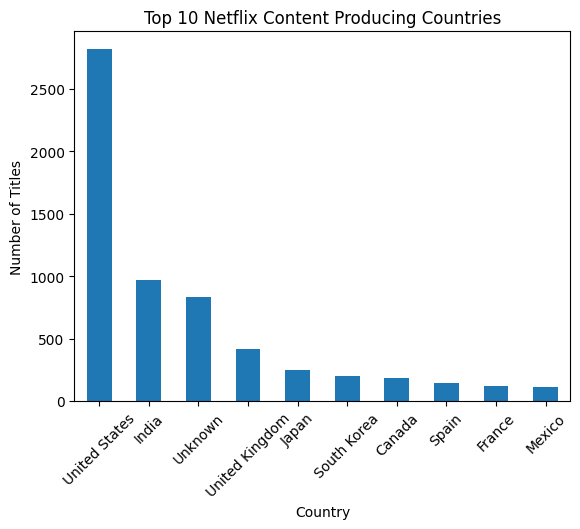

In [ ]:
top_countries = dataset['country'].value_counts().head(10)
plt.figure()
top_countries.plot(kind='bar')
plt.title("Top 10 Netflix Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

2. Line Chart representing how the number of titles added to Netflix has changed over the years

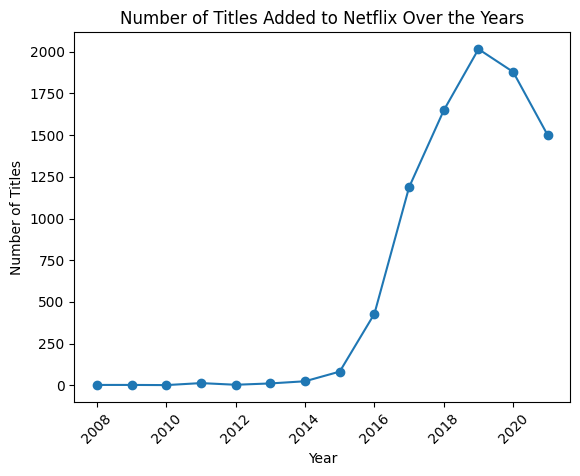

In [ ]:
dataset['year_added'] = dataset['date_added'].dt.year
yearly_counts = dataset['year_added'].value_counts().sort_index()

plt.figure()
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title("Number of Titles Added to Netflix Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

3. Histogram representing the ratio of movies released per year

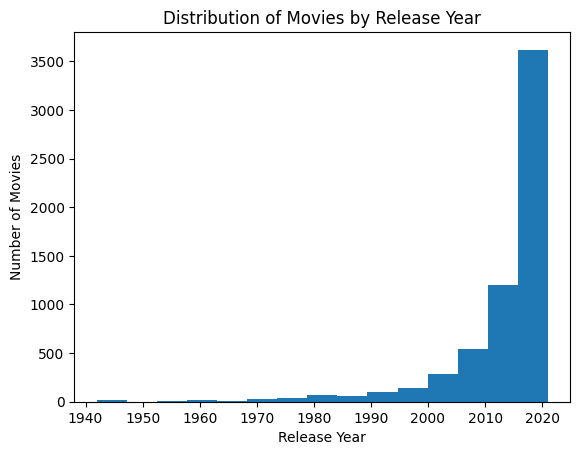

In [ ]:
movies = dataset[dataset['type'] == 'Movie']

plt.figure()
plt.hist(movies['release_year'], bins=15)
plt.title("Distribution of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()

4. Scatter Plot showing the relationship between release year and duration

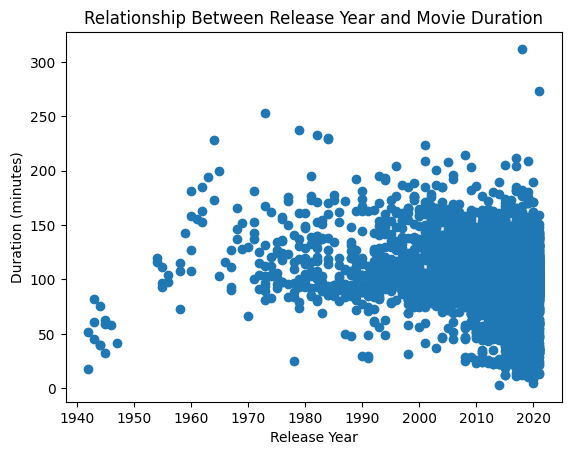

In [ ]:
movies = dataset[dataset['type'] == 'Movie'].copy()
movies['duration_int'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure()
plt.scatter(movies['release_year'], movies['duration_int'])

plt.title("Relationship Between Release Year and Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")

plt.show()

5. Pie Chart visualising top 5 content rating distribution

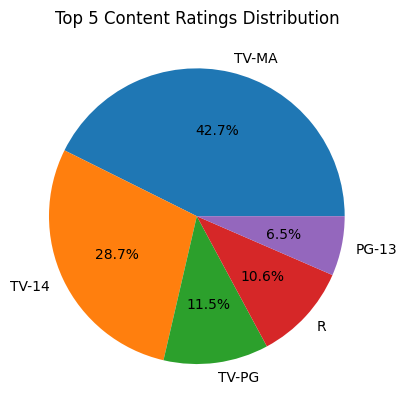

In [ ]:
rating_counts = dataset['rating'].value_counts().head(5)

plt.figure()
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%')

plt.title("Top 5 Content Ratings Distribution")

plt.show()

6. Heatmap representing the relationship between content added over years vs type

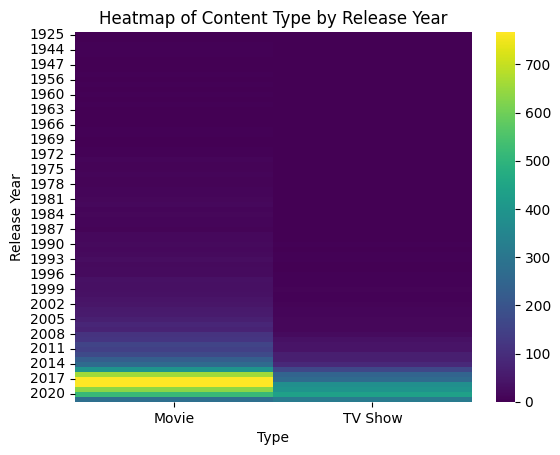

In [ ]:
pivot = dataset.pivot_table(index='release_year', columns='type', aggfunc='size', fill_value=0)

plt.figure()
sns.heatmap(pivot, cmap='viridis')

plt.title("Heatmap of Content Type by Release Year")

plt.xlabel("Type")
plt.ylabel("Release Year")

plt.show()

Step 5 — Insights Report

**Business / Research Insights**

1. **Content is dominated by a few countries**
   Most of the content comes from a small number of countries, which shows that Netflix relies heavily on certain regions for production. This also suggests there’s room to grow in less represented countries to make the platform more globally balanced.

2. **Netflix has been rapidly expanding its content library**
   Over the years, the number of titles added has increased significantly. This shows that Netflix is continuously investing in adding new content to keep users engaged and to stay competitive.

3. **Newer content is clearly preferred**
   A large number of movies are from recent years, which indicates that Netflix focuses more on modern content. This likely reflects audience preference, as viewers tend to watch newer releases more.

4. **Movie duration has stayed mostly consistent over time**
   There isn’t any strong change in movie length across different years. This suggests that the industry follows a fairly standard runtime, regardless of when the movie was made.

5. **Content is aimed at specific audience groups**
   A few rating categories dominate the platform, which means Netflix is mainly targeting particular types of viewers (like general audiences or mature viewers) rather than spreading evenly across all groups.


*Short Note on which finding surprised me the most:*

The most surprising finding was that movie duration has remained almost unchanged over the years. Despite major changes in the film industry and viewer preferences, the average length of movies has stayed fairly consistent. I expected newer movies to be shorter due to reduced attention spans, but the data did not support that.
